# UC2 — Modelado: Alerta predictiva de liquidez

**Autor:** Brayan Iván (`bi`)
**Proyecto:** datamoles — Havi
**Tipo:** Clasificación binaria supervisada
**Métrica clave:** Recall ≥ 0.75 (preferimos alertar de más que de menos)

## Objetivo

Predecir si un usuario no podrá cubrir sus compromisos financieros a fin del mes en curso.
La alerta debe activarse antes del déficit, no como reacción a un saldo negativo.

## Target

`deficit_fin_mes = 1` si `(gasto_estimado_fin_mes + carga_fija_total) > ingreso_mensual_mxn`,
equivalente a `score_riesgo > 1.0`.

## Estrategia

1. **Baseline**: `LogisticRegression(class_weight='balanced')` — interpretable.
2. **Principal**: `RandomForestClassifier(n_estimators=300, class_weight='balanced')`.
3. Sweep de threshold sobre el modelo principal para maximizar precisión bajo `recall ≥ 0.75`.
4. Feature importance del RF + coeficientes del LR.


---
## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import json, joblib
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, roc_auc_score, precision_recall_curve,
    confusion_matrix, precision_score, recall_score, f1_score
)

ROOT = Path('..').resolve().parent
FEAT_DIR  = ROOT / 'outputs' / 'features'
OUT_BASE  = ROOT / 'outputs'
OUT_UC2   = OUT_BASE / 'uc2'
MODELS_DIR= OUT_BASE / 'models'
FIG_DIR   = ROOT / 'notebooks' / 'uc2'
DATA_DIR  = ROOT / 'Datathon_Hey_2026_dataset_transacciones 1' / 'dataset_transacciones'

OUT_UC2.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

CUTOFF_DATE = pd.Timestamp('2025-10-31')
RANDOM_STATE = 42
print('FEAT_DIR  :', FEAT_DIR)
print('MODELS_DIR:', MODELS_DIR)


FEAT_DIR  : C:\Users\Fernando\Documents\GitHub\Datathon-2026\outputs\features
MODELS_DIR: C:\Users\Fernando\Documents\GitHub\Datathon-2026\outputs\models


## 1. Carga y merge de las 3 fuentes

In [2]:
df_personas = pd.read_parquet(FEAT_DIR / 'feat_uc2_personas.parquet')
df_score    = pd.read_csv(OUT_BASE / 'score_riesgo_usuarios.csv')

print('feat_uc2_personas       :', df_personas.shape)
print('score_riesgo_usuarios   :', df_score.shape)

df = df_personas.merge(
    df_score[['user_id','score_riesgo','delta_score_mensual',
              'gasto_estimado_fin_mes','carga_fija_total','ingreso_mensual_mxn',
              'ingreso_restante_estimado','dias_hasta_deficit','tendencia_riesgo']],
    on='user_id', how='inner'
)
print('Merged                  :', df.shape)
df.head(3)


feat_uc2_personas       : (15025, 68)
score_riesgo_usuarios   : (15025, 17)
Merged                  : (15025, 76)


,user_id,feat_dem_edad,feat_dem_edad_bin,feat_dem_sexo_H,feat_dem_sexo_M,feat_dem_sexo_SE,feat_dem_ingreso_log,feat_dem_ingreso_cuartil,feat_dem_antiguedad_dias,feat_dem_score_buro,...,feat_risk_pct_atipicas,feat_risk_pct_reintento,score_riesgo,delta_score_mensual,gasto_estimado_fin_mes,carga_fija_total,ingreso_mensual_mxn,ingreso_restante_estimado,dias_hasta_deficit,tendencia_riesgo
0,USR-00001,21,<26,False,True,False,10.106469,3.0,NaN,527,...,0.0,0.038462,0.158816,-0.047105,0.0,3891.0,24500,20609.0,inf,Mejorando
1,USR-00002,18,<26,False,True,False,9.852247,2.0,NaN,714,...,0.0,0.014706,0.246737,-0.073513,0.0,4688.0,19000,14312.0,inf,Mejorando
2,USR-00003,23,<26,True,False,False,9.546884,1.0,NaN,454,...,0.0,0.014085,0.253000,-0.058821,0.0,3542.0,14000,10458.0,inf,Mejorando


## 2. Construcción del target `deficit_fin_mes`

In [3]:
df['deficit_fin_mes'] = (df['ingreso_restante_estimado'] < 0).astype(int)

print('Distribución del target:')
print(df['deficit_fin_mes'].value_counts())
print(f'\nTasa positiva: {df["deficit_fin_mes"].mean():.1%}')
print(f'Coincidencia con score_riesgo > 1.0: {((df["deficit_fin_mes"]==1) == (df["score_riesgo"]>1.0)).mean():.1%}')


Distribución del target:
deficit_fin_mes
0    14985
1       40
Name: count, dtype: int64

Tasa positiva: 0.3%
Coincidencia con score_riesgo > 1.0: 100.0%


## 3. Feature `gasto_discrecional_pct`

No existe MCC "delivery" en el dataset. Usamos `restaurante + entretenimiento + servicios_digitales` como proxy de gasto discrecional, que es el predictor económicamente equivalente.

In [4]:
tx = pd.read_csv(DATA_DIR / 'hey_transacciones.csv',
                 usecols=['user_id','categoria_mcc','tipo_operacion','estatus','monto','fecha_hora'],
                 low_memory=False)
tx['fecha_hora'] = pd.to_datetime(tx['fecha_hora'], errors='coerce')
tx = tx[(tx['fecha_hora'] <= CUTOFF_DATE)
        & (tx['tipo_operacion']=='compra')
        & (tx['estatus']=='completada')]

DISC_MCC = {'restaurante','entretenimiento','servicios_digitales'}
discr = (tx.assign(_disc=tx['categoria_mcc'].isin(DISC_MCC))
            .groupby('user_id').apply(lambda g: g.loc[g['_disc'],'monto'].sum() / g['monto'].sum() if g['monto'].sum()>0 else 0)
            .rename('gasto_discrecional_pct').reset_index())

df = df.merge(discr, on='user_id', how='left')
df['gasto_discrecional_pct'] = df['gasto_discrecional_pct'].fillna(0.0)
print('Distribución gasto_discrecional_pct:')
print(df['gasto_discrecional_pct'].describe().to_string())


Distribución gasto_discrecional_pct:
count    15025.000000
mean         0.334329
std          0.258645
min          0.000000
25%          0.142236
50%          0.261655
75%          0.497799
max          1.000000


## 4. Selección de features (sin leakage)

Excluimos las variables que componen el target:
- `gasto_estimado_fin_mes`, `carga_fija_total`, `ingreso_restante_estimado`, `score_riesgo` (definen el target)
- `dias_hasta_deficit` (consecuencia directa del target)

Mantenemos `delta_score_mensual` (es snapshot del mes anterior, no leakage).

In [5]:
LEAKAGE_COLS = {
    'gasto_estimado_fin_mes','carga_fija_total','ingreso_restante_estimado',
    'score_riesgo','dias_hasta_deficit','tendencia_riesgo','ingreso_mensual_mxn',
}

# Features finales
FEATURES = [
    # snapshot temporal del riesgo
    'delta_score_mensual',
    # demografía
    'feat_dem_edad','feat_dem_ingreso_log','feat_dem_score_buro',
    'feat_dem_ingreso_cuartil','feat_dem_antiguedad_dias',
    # engagement
    'feat_eng_es_hey_pro','feat_eng_nomina_domiciliada','feat_eng_recibe_remesas',
    'feat_eng_satisfaccion','feat_eng_dias_desde_ultimo_login',
    # portafolio
    'feat_port_n_productos_activos',
    # comportamiento
    'feat_time_weekend_ratio','feat_time_nocturnal_ratio',
    # riesgo
    'feat_risk_n_rechazos_anual','feat_risk_n_rechazos_30d',
    'feat_risk_n_disputas','feat_risk_pct_atipicas','feat_risk_pct_reintento',
    # derivado
    'gasto_discrecional_pct',
]

# pct_ingreso_comprometido se deriva: carga_fija_total / ingreso_mensual_mxn
df['pct_ingreso_comprometido'] = (
    df['carga_fija_total'] / df['ingreso_mensual_mxn'].replace(0, np.nan)
).fillna(0).clip(upper=5.0)
FEATURES.append('pct_ingreso_comprometido')

# días al corte (constante para snapshot único, pero documentado para extensibilidad)
df['dias_al_corte'] = (pd.Timestamp(CUTOFF_DATE.year, CUTOFF_DATE.month, 28) - CUTOFF_DATE).days
FEATURES.append('dias_al_corte')

# Cast booleanos a int
for col in ['feat_eng_es_hey_pro','feat_eng_nomina_domiciliada','feat_eng_recibe_remesas']:
    df[col] = df[col].astype(int)

X = df[FEATURES].copy()
# Quitar features 100% NaN (no sirven al modelo y rompen el pipeline)
all_nan = [c for c in FEATURES if X[c].isna().all()]
if all_nan:
    print(f'Dropping all-NaN features: {all_nan}')
    FEATURES = [c for c in FEATURES if c not in all_nan]
    X = df[FEATURES].copy()
y = df['deficit_fin_mes'].copy()
print('Shape X:', X.shape, '| target rate:', y.mean().round(3))
print('NaN por columna (top 5):')
print(X.isna().sum().sort_values(ascending=False).head().to_string())


Dropping all-NaN features: ['feat_dem_antiguedad_dias']
Shape X: (15025, 21) | target rate: 0.003
NaN por columna (top 5):
feat_risk_n_rechazos_30d         12855
feat_risk_n_disputas              5314
feat_risk_n_rechazos_anual        4304
feat_port_n_productos_activos      817
feat_eng_satisfaccion              751


## 5. Split estratificado 80/20

*Nota:* el dataset es un snapshot por usuario (no series temporales), por eso usamos `stratify=y` en lugar de split temporal. Documentado como limitación del approach.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print('Train:', X_train.shape, 'Test:', X_test.shape)
print('Tasa positiva train/test:', y_train.mean().round(3), '/', y_test.mean().round(3))


Train: (12020, 21) Test: (3005, 21)
Tasa positiva train/test: 0.003 / 0.003


## 6. Entrenamiento — LR baseline + RF principal

In [7]:
pipe_lr = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('sc',  StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)),
])
pipe_rf = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('clf', RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                   random_state=RANDOM_STATE, n_jobs=-1)),
])

pipe_lr.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)
print('Modelos entrenados.')


Modelos entrenados.


## 7. Evaluación

In [8]:
def evaluar(pipe, name):
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, y_proba)
    print(f'\n=== {name} ===')
    print(f'AUC-ROC: {auc:.3f}')
    print(classification_report(y_test, y_pred, digits=3))
    return {'auc':auc,
            'precision':precision_score(y_test,y_pred),
            'recall':recall_score(y_test,y_pred),
            'f1':f1_score(y_test,y_pred),
            'y_proba':y_proba, 'y_pred':y_pred}

m_lr = evaluar(pipe_lr, 'Logistic Regression (baseline)')
m_rf = evaluar(pipe_rf, 'Random Forest (principal)')



=== Logistic Regression (baseline) ===
AUC-ROC: 0.998
              precision    recall  f1-score   support

           0      1.000     0.997     0.998      2997
           1      0.412     0.875     0.560         8

    accuracy                          0.996      3005
   macro avg      0.706     0.936     0.779      3005
weighted avg      0.998     0.996     0.997      3005




=== Random Forest (principal) ===
AUC-ROC: 1.000
              precision    recall  f1-score   support

           0      0.998     1.000     0.999      2997
           1      1.000     0.250     0.400         8

    accuracy                          0.998      3005
   macro avg      0.999     0.625     0.700      3005
weighted avg      0.998     0.998     0.997      3005



## 8. Sweep de threshold (RF) — buscar mínimo threshold con recall ≥ 0.75

In [9]:
thresholds = np.linspace(0.05, 0.95, 19)
sweep = []
for t in thresholds:
    yp = (m_rf['y_proba'] >= t).astype(int)
    sweep.append({
        'threshold': float(t),
        'precision': precision_score(y_test, yp, zero_division=0),
        'recall':    recall_score(y_test, yp, zero_division=0),
        'f1':        f1_score(y_test, yp, zero_division=0),
        'n_alertas': int(yp.sum()),
    })
sweep_df = pd.DataFrame(sweep)
print(sweep_df.round(3).to_string(index=False))

# Threshold óptimo: el que mantiene recall>=0.75 y maximiza precision
ok = sweep_df[sweep_df['recall'] >= 0.75]
if len(ok):
    best = ok.sort_values('precision', ascending=False).iloc[0]
else:
    # fallback: threshold con mayor recall
    best = sweep_df.sort_values('recall', ascending=False).iloc[0]
threshold_opt = float(best['threshold'])
print(f'\nThreshold óptimo: {threshold_opt:.2f}  | precision={best["precision"]:.3f}  recall={best["recall"]:.3f}  f1={best["f1"]:.3f}')


 threshold  precision  recall    f1  n_alertas
      0.05      0.800   1.000 0.889         10
      0.10      0.889   1.000 0.941          9
      0.15      0.875   0.875 0.875          8
      0.20      1.000   0.875 0.933          7
      0.25      1.000   0.875 0.933          7
      0.30      1.000   0.875 0.933          7
      0.35      1.000   0.875 0.933          7
      0.40      1.000   0.750 0.857          6
      0.45      1.000   0.500 0.667          4
      0.50      1.000   0.250 0.400          2
      0.55      1.000   0.250 0.400          2
      0.60      1.000   0.250 0.400          2
      0.65      1.000   0.125 0.222          1
      0.70      1.000   0.125 0.222          1
      0.75      1.000   0.125 0.222          1
      0.80      0.000   0.000 0.000          0
      0.85      0.000   0.000 0.000          0
      0.90      0.000   0.000 0.000          0
      0.95      0.000   0.000 0.000          0

Threshold óptimo: 0.20  | precision=1.000  recall=0.875  f1

## 9. Feature importance (RF) + coeficientes (LR)

                         feature  importance_rf  coef_lr
            feat_dem_ingreso_log         0.3010  -0.7589
        pct_ingreso_comprometido         0.2443   4.7968
        feat_dem_ingreso_cuartil         0.1664  -0.3070
             delta_score_mensual         0.0678   4.7231
             feat_dem_score_buro         0.0376   0.0974
          gasto_discrecional_pct         0.0315  -0.4330
         feat_risk_pct_reintento         0.0293   0.5062
feat_eng_dias_desde_ultimo_login         0.0257  -1.5596
         feat_time_weekend_ratio         0.0183  -0.3375
      feat_risk_n_rechazos_anual         0.0174  -0.3277


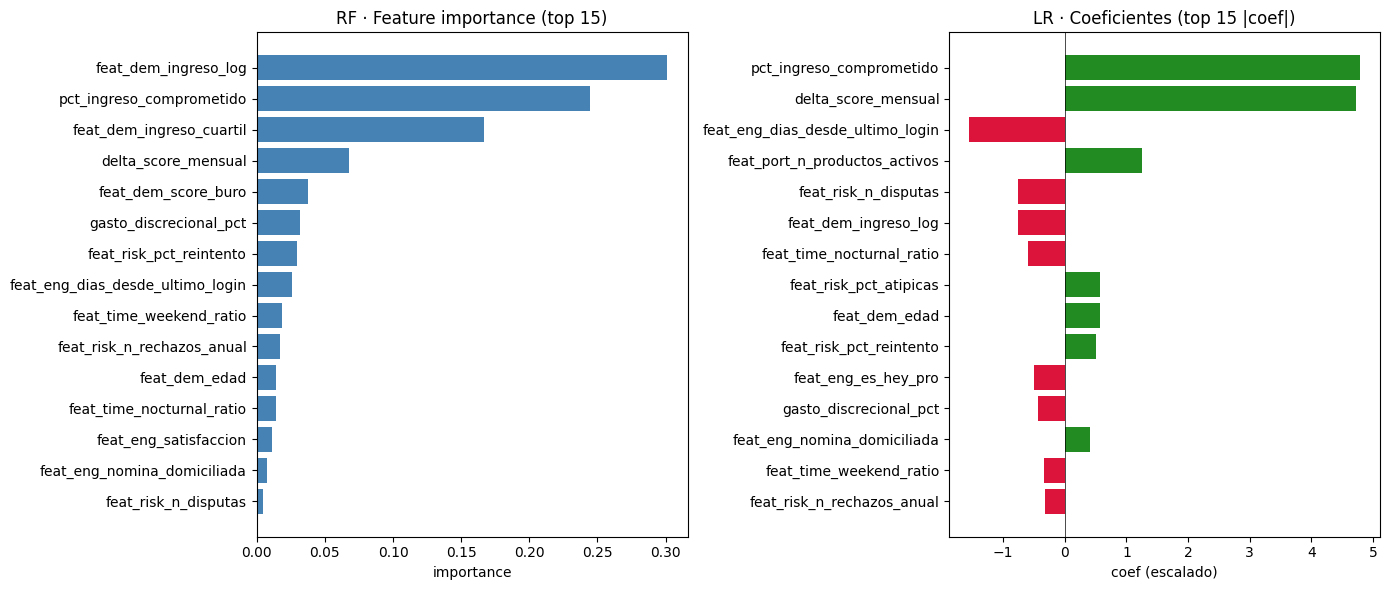

In [10]:
fi = pd.DataFrame({
    'feature': FEATURES,
    'importance_rf': pipe_rf.named_steps['clf'].feature_importances_,
    'coef_lr': pipe_lr.named_steps['clf'].coef_[0],
}).sort_values('importance_rf', ascending=False)
print(fi.head(10).round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
top_fi = fi.head(15).iloc[::-1]
axes[0].barh(top_fi['feature'], top_fi['importance_rf'], color='steelblue')
axes[0].set_title('RF · Feature importance (top 15)')
axes[0].set_xlabel('importance')

top_lr = fi.assign(abs_coef=fi['coef_lr'].abs()).sort_values('abs_coef', ascending=False).head(15).iloc[::-1]
axes[1].barh(top_lr['feature'], top_lr['coef_lr'],
             color=['crimson' if c<0 else 'forestgreen' for c in top_lr['coef_lr']])
axes[1].set_title('LR · Coeficientes (top 15 |coef|)')
axes[1].set_xlabel('coef (escalado)')
axes[1].axvline(0, color='black', lw=0.5)
plt.tight_layout()
plt.savefig(FIG_DIR / 'uc2_fig_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()


## 10. PR curve + matriz de confusión al threshold óptimo

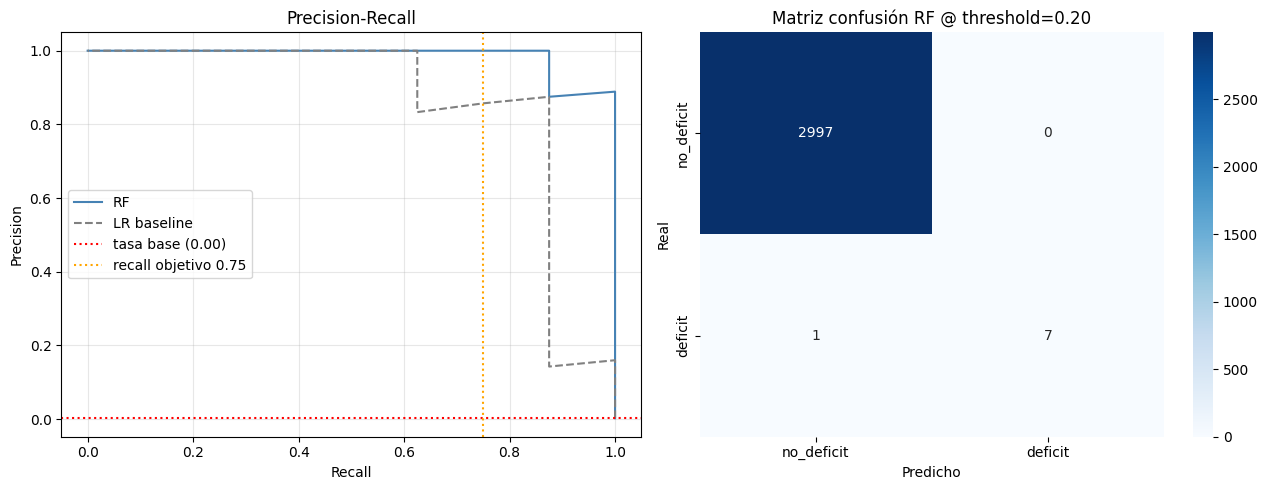

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
prec, rec, _ = precision_recall_curve(y_test, m_rf['y_proba'])
axes[0].plot(rec, prec, color='steelblue', label='RF')
prec_lr, rec_lr, _ = precision_recall_curve(y_test, m_lr['y_proba'])
axes[0].plot(rec_lr, prec_lr, color='gray', linestyle='--', label='LR baseline')
axes[0].axhline(y_test.mean(), color='red', linestyle=':', label=f'tasa base ({y_test.mean():.2f})')
axes[0].axvline(0.75, color='orange', linestyle=':', label='recall objetivo 0.75')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall'); axes[0].legend(); axes[0].grid(alpha=.3)

yp_opt = (m_rf['y_proba'] >= threshold_opt).astype(int)
cm = confusion_matrix(y_test, yp_opt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['no_deficit','deficit'], yticklabels=['no_deficit','deficit'])
axes[1].set_title(f'Matriz confusión RF @ threshold={threshold_opt:.2f}')
axes[1].set_xlabel('Predicho'); axes[1].set_ylabel('Real')
plt.tight_layout()
plt.savefig(FIG_DIR / 'uc2_fig_pr_curve.png', dpi=120, bbox_inches='tight')
plt.show()


## 11. Persistencia

In [12]:
joblib.dump(pipe_rf, MODELS_DIR / 'uc2_liquidez_rf.pkl')
joblib.dump(pipe_lr, MODELS_DIR / 'uc2_liquidez_lr_baseline.pkl')

metrics_out = {
    'fecha_evaluacion': pd.Timestamp.utcnow().isoformat(),
    'features_usadas': FEATURES,
    'n_train': int(len(X_train)),
    'n_test':  int(len(X_test)),
    'tasa_positiva_total': float(y.mean()),
    'modelos': {
        'logistic_regression': {
            'auc_roc':   float(m_lr['auc']),
            'precision': float(m_lr['precision']),
            'recall':    float(m_lr['recall']),
            'f1':        float(m_lr['f1']),
        },
        'random_forest': {
            'auc_roc':   float(m_rf['auc']),
            'precision_default': float(m_rf['precision']),
            'recall_default':    float(m_rf['recall']),
            'f1_default':        float(m_rf['f1']),
            'threshold_optimo':  float(threshold_opt),
            'precision_threshold_opt': float(best['precision']),
            'recall_threshold_opt':    float(best['recall']),
            'f1_threshold_opt':        float(best['f1']),
        }
    },
    'criterios_aceptacion': {
        'auc_rf_gt_0.70':    bool(m_rf['auc'] > 0.70),
        'recall_rf_gt_0.75': bool(best['recall'] > 0.75),
    },
    'feature_importance_top10': fi.head(10).set_index('feature')['importance_rf'].round(4).to_dict(),
    'threshold_sweep': sweep_df.round(4).to_dict(orient='records'),
}

with open(OUT_UC2 / 'uc2_metrics.json','w', encoding='utf-8') as f:
    json.dump(metrics_out, f, indent=2, default=str, ensure_ascii=False)

print('OK')
print(' modelo RF:', MODELS_DIR / 'uc2_liquidez_rf.pkl')
print(' modelo LR:', MODELS_DIR / 'uc2_liquidez_lr_baseline.pkl')
print(' metrics:  ', OUT_UC2 / 'uc2_metrics.json')


OK
 modelo RF: C:\Users\Fernando\Documents\GitHub\Datathon-2026\outputs\models\uc2_liquidez_rf.pkl
 modelo LR: C:\Users\Fernando\Documents\GitHub\Datathon-2026\outputs\models\uc2_liquidez_lr_baseline.pkl
 metrics:   C:\Users\Fernando\Documents\GitHub\Datathon-2026\outputs\uc2\uc2_metrics.json
